In [1]:
import sys
sys.path.append('../')

import numpy as np
import scipy.sparse as ssp
import matplotlib.pyplot as plt
import qutip as qt
import scqubits as scq
from matplotlib.colors import LogNorm
from tqdm import tqdm
from qutip.qip.operations import rz, cz_gate
import cmath
from sympy import symbols
import utils_2Q_gate_zp as ut
import scipy as sp
from joblib import Parallel, delayed
import pandas as pd
import itertools

cnot = pd.read_csv('data/data_cnot_fidelity_3ncut.txt')
# df = pd.DataFrame(p, columns=['tg', 'drive_amp_1', 'drive_amp_2', 'detune_1',
#                                    'detune_2', 'f_200_select', 'f_1000_False',  ])
# df.to_csv('data/data_cnot_fidelity_3ncut.txt', sep=',', index=False, header=True)

In [2]:
tg = np.array([50, 100, 150, 200, 250, 300])
f_82 = np.array([-0.5056, -0.9911, -1.9102, -2.6448, -3.0627, -3.3197])
f_45 = np.array([-0.44844628, -0.71081281, -1.0108689, -1.35828237 , -1.66780924 , -2.11534 ])
f_80 = np.array([-0.43179258, -0.98179645, -0.90868406, -1.4291463 ,-2.41803395, -1.56986579 , ])
f_14 = np.array([-0.53854224, -0.67098751, -1.53119739, -1.31950773 ,-1.34589397, -2.05983138 , ])
f_41 = np.array([-0.43969532, -0.66707256, -0.99897258, -0.99422293 ,-1.33884472, -1.66755058 , ])

p82 = np.array([
    [50.008813,0.090273,0.046546,-0.027498,-0.025767,],
    [100.006167,0.053076,0.029316,-0.01188,-0.01157,],
    [149.996866,0.039078,0.024359,-0.009107,-0.008681,],
    [200.001513,0.029121,0.018721,-0.005572,-0.005265,],
    [249.992868,0.022922,0.014688,-0.003423,-0.003252,],
    [300.003294,0.018943,0.012103,-0.002317,-0.002203,],    
])
p45 = np.array([
[50.000812, 0.178565, 0.07488, -0.067799, -0.060233] ,
[100.002376, 0.179025, 0.069014, -0.070589, -0.075774] ,
[150.006597, 0.176563, 0.067618, -0.074074, -0.078549] ,
[199.992327, 0.181496, 0.064716, -0.078021, -0.080796] , 
[250.010821, 0.131137, 0.043355, -0.040946, -0.045208] ,
[300.00522294, 0.13810474, 0.04110462, -0.04429244, -0.04778556],
])
p80 = np.array([
[49.997949, 0.180972, 0.052916, -0.09377, -0.092834] ,
[100.013043, 0.052558, 0.029442, 0.011978, 0.012001] ,
[150.010557, 0.179616, 0.04417, 0.04109, 0.046445] ,
[200.002602, 0.090035, 0.038235, 0.006, 0.001833] ,
])
p14 = np.array([
[50.000399, 0.092851, 0.043391, -0.080654, -0.080743] ,
[100.009419, 0.156132, 0.06599, 0.070482, 0.068753] ,
[150.00347, 0.061863, 0.039491, -0.065887, -0.064554] ,
[200.007078, 0.159118, 0.057099, 0.071357, 0.066645] ,
[249.99778247, 0.13949621, 0.08671947, 0.03985119, 0.04145855]
])
W0_82 =  45.546 
W1_82 =  23.753
W0_45 =  46.741 
W1_45 =  24.947
W0_80 =  45.393 
W1_80 =  23.599
W0_14 =  45.897
W1_14 =  24.103

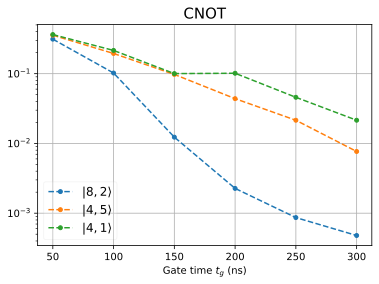

In [5]:
fig, ax = plt.subplots(figsize=(6,4))
ms=8
ax.plot(tg, 10**f_82, '.--',  label=r'$|8,2\rangle$', ms=ms)
ax.plot(tg, 10**f_45, '.--',  label=r'$|4,5\rangle$', ms=ms)
# ax.plot(tg, 10**f_80, '.--',  label=r'$|1,4\rangle$', ms=ms)
# ax.plot(tg, 10**f_14, '.--',  label=r'$|8,0\rangle$', ms=ms)
ax.plot(tg, 10**f_41, '.--',  label=r'$|4,1\rangle$', ms=ms)

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title(r'CNOT', fontsize=15)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [3]:
f_170us_v2 = np.array([
-0.30835595, -0.67293207, -0.92582623, -1.34352008 ,
-1.92191799, -2.40261036, -2.71718386, -2.88386487 ,
-2.9884978, -3.06483296, -3.1060151 ,
])
f_30us_v2 = np.array([
-0.30830752, -0.67228223, -0.92386404, -1.33598866 ,
-1.88736934, -2.28952363, -2.48175774, -2.53625982 ,
-2.5473369, -2.54147911, -2.52255582 ,
])
f_3us_v2 = np.array([
-0.30767897, -0.66542678, -0.90338169, -1.26266108 ,
-1.62756485, -1.75112556, -1.74581363, -1.70675385 ,
-1.66415968, -1.62418208, -1.58601431 ,
                    ])
v2_ideal = np.array([
-0.30837105, -0.67306385, -0.92636722, -1.3451509 ,
-1.92947956, -2.43016406, -2.78525417, -2.99885625 ,
-3.16576048, -3.31975139, -3.44178535 ,
])
v2 = np.array([
[30.016865, 0.119046, 0.056799, -0.032063, -0.030732] ,
[60.024831, 0.074075, 0.039782, -0.020488, -0.019859] ,
[90.004882, 0.057133, 0.030909, -0.013363, -0.01325] ,
[119.999923, 0.046969, 0.027146, -0.010649, -0.010409] ,
[149.996866, 0.039078, 0.024359, -0.009107, -0.008681] ,
[179.996641, 0.032821, 0.02095, -0.006902, -0.006534] ,
[209.996351, 0.02774, 0.017771, -0.005024, -0.004777] ,
[239.989977, 0.023957, 0.015387, -0.003744, -0.003546] ,
[269.994868, 0.021106, 0.013544, -0.002882, -0.002747] ,
[300.003294, 0.018943, 0.012103, -0.002317, -0.002203] ,
[330.004173, 0.017153, 0.010944, -0.001891, -0.001804] ,
])
v2tot = np.column_stack((v2, np.round(v2_ideal, 8), np.round(f_170us_v2, 8), np.round(f_30us_v2, 8), np.round(f_3us_v2, 8)))

In [4]:
f_170us_v3 = np.array([
-0.4191225, -0.76026815, -1.01283927, -1.57551592 ,
-2.06772623, -2.52107117, -2.79447264, -2.93855216 ,
-3.02634505, -3.07971574, -3.11338393 ,
])
f_30us_v3 = np.array([
-0.41897177, -0.75928846, -1.01009786, -1.56149978 ,
-2.01742264, -2.37182427, -2.51157853, -2.54920101 ,
-2.55006294, -2.53543518, -2.51462029 ,
])
f_3us_v3 = np.array([
-0.41727262, -0.74899092, -0.98184342, -1.43488875 ,
-1.68035308, -1.756333, -1.73430151, -1.69328746 ,
-1.650947, -1.61096689, -1.57387751 ,
                    ])
v3_ideal = np.array([
-0.41915456, -0.76053762, -1.01368202, -1.57841328 ,
-2.07880109, -2.559748, -2.86702638, -3.07743822 ,
-3.231448, -3.35914688, -3.47419315 ,
])
v3 = np.array([
[40.016766, 0.104833, 0.049914, -0.030496, -0.028693] ,
[69.994995, 0.065867, 0.034625, -0.016253, -0.015833] ,
[100.006167, 0.053076, 0.029316, -0.01188, -0.01157] ,
[129.995414, 0.044102, 0.026819, -0.010756, -0.010313] ,
[160.000133, 0.036595, 0.022959, -0.008237, -0.007826] ,
[189.997344, 0.030915, 0.019755, -0.006194, -0.005848] ,
[219.997562, 0.026349, 0.016887, -0.00455, -0.004302] ,
[249.992868, 0.022922, 0.014688, -0.003423, -0.003252] ,
[280.000886, 0.020289, 0.013002, -0.002675, -0.002543] ,
[310.008159, 0.018298, 0.011686, -0.002157, -0.002061] ,
[340.0063, 0.016618, 0.010608, -0.001774, -0.00169] ,
])
v3tot = np.column_stack((v3, np.round(v3_ideal, 8), np.round(f_170us_v3, 8), np.round(f_30us_v3, 8), np.round(f_3us_v3, 8)))

In [5]:
f_170us_v4 = np.array([
-0.54742244, -0.85594136, -1.15614814, -1.78517221 ,
-2.25546, -2.62218171, -2.83387231, -2.96894481 ,
-3.0476778, -3.09298378 ,
])
f_30us_v4 = np.array([
-0.54707323, -0.8544846, -1.15180115, -1.76126065 ,
-2.17590113, -2.43191869, -2.52261034, -2.55062065 ,
-2.54627393, -2.52869477 ,
])
f_3us_v4 = np.array([
-0.54329492, -0.83918438, -1.10781324, -1.5643863 ,
-1.73089226, -1.75332546, -1.71995833, -1.67877089 ,
-1.6370597, -1.59791789 ,
                    ])
v4_ideal = np.array([
-0.54748191, -0.85632286, -1.15704733, -1.79033564 ,
-2.27285841, -2.6736226, -2.92928646, -3.12760541 ,
-3.27816315, -3.39717795 ,
])
v4 = np.array([
[50.008813, 0.090273, 0.046546, -0.027498, -0.025767] ,
[80.005168, 0.061271, 0.032441, -0.015181, -0.014477] ,
[110.008706, 0.049616, 0.028206, -0.01119, -0.010777] ,
[140.005331, 0.041394, 0.025794, -0.010206, -0.009612] ,
[169.993992, 0.034622, 0.02211, -0.007681, -0.007266] ,
[200.001513, 0.029121, 0.018721, -0.005572, -0.005265] ,
[230.001715, 0.025067, 0.016064, -0.00409, -0.003877] ,
[260.000623, 0.021992, 0.014066, -0.003138, -0.002978] ,
[290.001675, 0.019575, 0.01252, -0.00247, -0.002353] ,
[319.999489, 0.01768, 0.011265, -0.002005, -0.001905] ,
])
v4tot = np.column_stack((v4, np.round(v4_ideal, 8), np.round(f_170us_v4, 8), np.round(f_30us_v4, 8), np.round(f_3us_v4, 8)))
arr = np.row_stack((v2tot, v3tot, v4tot))
sorted_arr = arr[np.argsort(arr[:, 0])]
for i in range(len(sorted_arr)):
    print(sorted_arr[i].tolist(), ',')

[30.016865, 0.119046, 0.056799, -0.032063, -0.030732, -0.30837105, -0.30835595, -0.30830752, -0.30767897] ,
[40.016766, 0.104833, 0.049914, -0.030496, -0.028693, -0.41915456, -0.4191225, -0.41897177, -0.41727262] ,
[50.008813, 0.090273, 0.046546, -0.027498, -0.025767, -0.54748191, -0.54742244, -0.54707323, -0.54329492] ,
[60.024831, 0.074075, 0.039782, -0.020488, -0.019859, -0.67306385, -0.67293207, -0.67228223, -0.66542678] ,
[69.994995, 0.065867, 0.034625, -0.016253, -0.015833, -0.76053762, -0.76026815, -0.75928846, -0.74899092] ,
[80.005168, 0.061271, 0.032441, -0.015181, -0.014477, -0.85632286, -0.85594136, -0.8544846, -0.83918438] ,
[90.004882, 0.057133, 0.030909, -0.013363, -0.01325, -0.92636722, -0.92582623, -0.92386404, -0.90338169] ,
[100.006167, 0.053076, 0.029316, -0.01188, -0.01157, -1.01368202, -1.01283927, -1.01009786, -0.98184342] ,
[110.008706, 0.049616, 0.028206, -0.01119, -0.010777, -1.15704733, -1.15614814, -1.15180115, -1.10781324] ,
[119.999923, 0.046969, 0.027146,

In [9]:
f_170us_v4 = np.array([
-0.33462568, -0.50387591, -0.71441306, -0.88778315 ,
-1.14713894, -1.52044528, -1.84979165 ,
-0.41730378, -0.61874912, -0.80501265, -0.99626745 ,
-1.33107376, -1.69573721 ,
])
v4_ideal = np.array([
-0.33459521, -0.50384835, -0.71460473, -0.8878994 ,
-1.14865398, -1.52765589, -1.84350299 ,
-0.41726832, -0.6187361, -0.80506117, -0.99644971 ,
-1.33083181, -1.70064316 ,
])
v4 = np.array([
[30.016865, 0.119046, 0.056799, -0.032063, -0.030732] ,
[50.008813, 0.090273, 0.046546, -0.027498, -0.025767] ,
[69.994995, 0.065867, 0.034625, -0.016253, -0.015833] ,
[90.004882, 0.057133, 0.030909, -0.013363, -0.01325] ,
[110.008706, 0.049616, 0.028206, -0.01119, -0.010777] ,
[129.995414, 0.044102, 0.026819, -0.010756, -0.010313] ,
[149.996866, 0.039078, 0.024359, -0.009107, -0.008681] ,

[40.016766, 0.104833, 0.049914, -0.030496, -0.028693] ,
[60.024831, 0.074075, 0.039782, -0.020488, -0.019859] ,
[80.005168, 0.061271, 0.032441, -0.015181, -0.014477] ,
[100.006167, 0.053076, 0.029316, -0.01188, -0.01157] ,
[119.999923, 0.046969, 0.027146, -0.010649, -0.010409] ,
[140.005331, 0.041394, 0.025794, -0.010206, -0.009612] ,
])
v4tot = np.column_stack((v4, np.round(v4_ideal, 8), np.round(f_170us_v4, 8)))
arr = np.row_stack(( v4tot))
sorted_arr = arr[np.argsort(arr[:, 0])]


f_30us_v4 = np.array([
-0.33455696, -0.41715523, -0.50360602, -0.61827326 ,
-0.71360372, -0.80374221, -0.88593046, -0.99347607 ,
-1.14258346, -1.32027945, -1.50563976, -1.67124937 ,
-1.81829787 ,
])
f_3us_v4 = np.array([
-0.33386244, -0.415659, -0.50076075, -0.61266715 ,
-0.70451341, -0.79028775, -0.8672338, -0.96618269 ,
-1.09931156, -1.24822082, -1.39281989, -1.50208234 ,
-1.57871225 ,
])

sorted_arr = np.column_stack((sorted_arr, np.round(f_30us_v4, 8), np.round(f_3us_v4, 8)))

for i in range(len(sorted_arr)):
    print(sorted_arr[i].tolist(), ',')

[30.016865, 0.119046, 0.056799, -0.032063, -0.030732, -0.33459521, -0.33462568, -0.33455696, -0.33386244] ,
[40.016766, 0.104833, 0.049914, -0.030496, -0.028693, -0.41726832, -0.41730378, -0.41715523, -0.415659] ,
[50.008813, 0.090273, 0.046546, -0.027498, -0.025767, -0.50384835, -0.50387591, -0.50360602, -0.50076075] ,
[60.024831, 0.074075, 0.039782, -0.020488, -0.019859, -0.6187361, -0.61874912, -0.61827326, -0.61266715] ,
[69.994995, 0.065867, 0.034625, -0.016253, -0.015833, -0.71460473, -0.71441306, -0.71360372, -0.70451341] ,
[80.005168, 0.061271, 0.032441, -0.015181, -0.014477, -0.80506117, -0.80501265, -0.80374221, -0.79028775] ,
[90.004882, 0.057133, 0.030909, -0.013363, -0.01325, -0.8878994, -0.88778315, -0.88593046, -0.8672338] ,
[100.006167, 0.053076, 0.029316, -0.01188, -0.01157, -0.99644971, -0.99626745, -0.99347607, -0.96618269] ,
[110.008706, 0.049616, 0.028206, -0.01119, -0.010777, -1.14865398, -1.14713894, -1.14258346, -1.09931156] ,
[119.999923, 0.046969, 0.027146, -0

In [ ]:
sorted_arr = np.array([
[30.016865, 0.119046, 0.056799, -0.032063, -0.030732, -0.33459521, -0.33462568, -0.33455696, -0.33386244] ,
[40.016766, 0.104833, 0.049914, -0.030496, -0.028693, -0.41726832, -0.41730378, -0.41715523, -0.415659] ,
[50.008813, 0.090273, 0.046546, -0.027498, -0.025767, -0.50384835, -0.50387591, -0.50360602, -0.50076075] ,
[60.024831, 0.074075, 0.039782, -0.020488, -0.019859, -0.6187361, -0.61874912, -0.61827326, -0.61266715] ,
[69.994995, 0.065867, 0.034625, -0.016253, -0.015833, -0.71460473, -0.71441306, -0.71360372, -0.70451341] ,
[80.005168, 0.061271, 0.032441, -0.015181, -0.014477, -0.80506117, -0.80501265, -0.80374221, -0.79028775] ,
[90.004882, 0.057133, 0.030909, -0.013363, -0.01325, -0.8878994, -0.88778315, -0.88593046, -0.8672338] ,
[100.006167, 0.053076, 0.029316, -0.01188, -0.01157, -0.99644971, -0.99626745, -0.99347607, -0.96618269] ,
[110.008706, 0.049616, 0.028206, -0.01119, -0.010777, -1.14865398, -1.14713894, -1.14258346, -1.09931156] ,
[119.999923, 0.046969, 0.027146, -0.010649, -0.010409, -1.33083181, -1.33107376, -1.32027945, -1.24822082] ,
[129.995414, 0.044102, 0.026819, -0.010756, -0.010313, -1.52765589, -1.52044528, -1.50563976, -1.39281989] ,
[140.005331, 0.041394, 0.025794, -0.010206, -0.009612, -1.70064316, -1.69573721, -1.67124937, -1.50208234] ,
[149.996866, 0.039078, 0.024359, -0.009107, -0.008681, -1.84350299, -1.84979165, -1.81829787, -1.57871225] ,
[160.000133, 0.036595, 0.022959, -0.008237, -0.007826, -2.07880109, -2.06772623, -2.01742264, -1.68035308] ,
[169.993992, 0.034622, 0.02211, -0.007681, -0.007266, -2.27285841, -2.25546, -2.17590113, -1.73089226] ,
[179.996641, 0.032821, 0.02095, -0.006902, -0.006534, -2.43016406, -2.40261036, -2.28952363, -1.75112556] ,
[189.997344, 0.030915, 0.019755, -0.006194, -0.005848, -2.559748, -2.52107117, -2.37182427, -1.756333] ,
[200.001513, 0.029121, 0.018721, -0.005572, -0.005265, -2.6736226, -2.62218171, -2.43191869, -1.75332546] ,
[209.996351, 0.02774, 0.017771, -0.005024, -0.004777, -2.78525417, -2.71718386, -2.48175774, -1.74581363] ,
[219.997562, 0.026349, 0.016887, -0.00455, -0.004302, -2.86702638, -2.79447264, -2.51157853, -1.73430151] ,
[230.001715, 0.025067, 0.016064, -0.00409, -0.003877, -2.92928646, -2.83387231, -2.52261034, -1.71995833] ,
[239.989977, 0.023957, 0.015387, -0.003744, -0.003546, -2.99885625, -2.88386487, -2.53625982, -1.70675385] ,
[249.992868, 0.022922, 0.014688, -0.003423, -0.003252, -3.07743822, -2.93855216, -2.54920101, -1.69328746] ,
[260.000623, 0.021992, 0.014066, -0.003138, -0.002978, -3.12760541, -2.96894481, -2.55062065, -1.67877089] ,
[269.994868, 0.021106, 0.013544, -0.002882, -0.002747, -3.16576048, -2.9884978, -2.5473369, -1.66415968] ,
[280.000886, 0.020289, 0.013002, -0.002675, -0.002543, -3.231448, -3.02634505, -2.55006294, -1.650947] ,
[290.001675, 0.019575, 0.01252, -0.00247, -0.002353, -3.27816315, -3.0476778, -2.54627393, -1.6370597] ,
[300.003294, 0.018943, 0.012103, -0.002317, -0.002203, -3.31975139, -3.06483296, -2.54147911, -1.62418208] ,
[310.008159, 0.018298, 0.011686, -0.002157, -0.002061, -3.35914688, -3.07971574, -2.53543518, -1.61096689] ,
[319.999489, 0.01768, 0.011265, -0.002005, -0.001905, -3.39717795, -3.09298378, -2.52869477, -1.59791789] ,
[330.004173, 0.017153, 0.010944, -0.001891, -0.001804, -3.44178535, -3.1060151, -2.52255582, -1.58601431] ,
[340.0063, 0.016618, 0.010608, -0.001774, -0.00169, -3.47419315, -3.11338393, -2.51462029, -1.57387751] ,
])
# df = pd.DataFrame(p, columns=['tg', 'drive_amp_1', 'drive_amp_2', 'detune_1',
#                                    'detune_2', 'f_200_select', 'f_1000_False',  ])
# df.to_csv('data/data_cnot_fidelity_3ncut.txt', sep=',', index=False, header=True)

In [ ]:
cnot['f_truc110_ideal'] = sorted_arr[:, 5]
cnot['f_truc110_170us'] = sorted_arr[:, 6]
cnot['f_truc110_30us'] = sorted_arr[:, 7]
cnot['f_truc110_3us'] = sorted_arr[:, 8]
# cnot.to_csv('data/data_cnot_fidelity_3ncut.txt', sep=',', index=False, header=True)
cnot

,tg,drive_amp_1,drive_amp_2,detune_1,detune_2,f_200_select,f_1000_False,f_truc110_ideal,f_truc110_170us,f_truc110_30us,f_truc110_3us
0,30.016865,0.119046,0.056799,-0.032063,-0.030732,-0.327715,-0.340550,-0.334595,-0.334626,-0.334557,-0.333862
1,40.016766,0.104833,0.049914,-0.030496,-0.028693,-0.404795,-0.419977,-0.417268,-0.417304,-0.417155,-0.415659
2,50.008813,0.090273,0.046546,-0.027498,-0.025767,-0.502482,-0.505646,-0.503848,-0.503876,-0.503606,-0.500761
3,60.024831,0.074075,0.039782,-0.020488,-0.019859,-0.612233,-0.593984,-0.618736,-0.618749,-0.618273,-0.612667
4,69.994995,0.065867,0.034625,-0.016253,-0.015833,-0.710713,-0.687095,-0.714605,-0.714413,-0.713604,-0.704513
5,80.005168,0.061271,0.032441,-0.015181,-0.014477,-0.808721,-0.780706,-0.805061,-0.805013,-0.803742,-0.790288
6,90.004882,0.057133,0.030909,-0.013363,-0.013250,-0.899877,-0.876855,-0.887899,-0.887783,-0.885930,-0.867234
7,100.006167,0.053076,0.029316,-0.011880,-0.011570,-1.007470,-0.991190,-0.996450,-0.996267,-0.993476,-0.966183
8,110.008706,0.049616,0.028206,-0.011190,-0.010777,-1.161067,-1.143754,-1.148654,-1.147139,-1.142583,-1.099312
9,119.999923,0.046969,0.027146,-0.010649,-0.010409,-1.352823,-1.325037,-1.330832,-1.331074,-1.320279,-1.248221


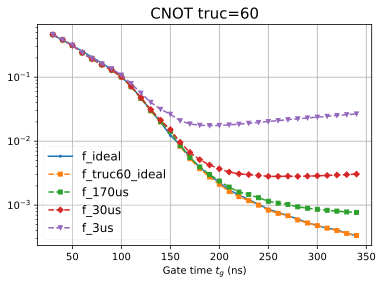

In [12]:
fig, ax = plt.subplots(figsize=(6,4))
ms=4
ax.plot(cnot['tg'], 10**cnot['f_1000_False'], '.-',  label=r'f_ideal', ms=ms)
ax.plot(sorted_arr[:,0], 10**sorted_arr[:,5], 's--',  label=r'f_truc60_ideal', ms=ms)
ax.plot(sorted_arr[:,0], 10**sorted_arr[:,6], 's--',  label=r'f_170us', ms=ms)
ax.plot(sorted_arr[:,0], 10**sorted_arr[:,7], 'D--',  label=r'f_30us', ms=ms)
ax.plot(sorted_arr[:,0], 10**sorted_arr[:,8], 'v--',  label=r'f_3us', ms=ms)
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title(r'CNOT truc=60', fontsize=15)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

In [8]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

In [ ]:
f_100_select = np.array([
-0.29959668, -0.37641895, -0.47861723, -0.60666134, -0.72551985,
-0.83960942, -0.92840786, -1.01425332, -1.15043255, -1.33161182,
-1.55658826, -1.77091185, -1.92250542, -2.06536472, -2.2534972,
-2.41437864, -2.54093738, -2.65215528, -2.764731, -2.84939887,
-2.91926708, -2.99295654, -3.06882559, -3.12323214, -3.16987398,
-3.22965957, -3.28333998, -3.32459057, -3.36338371, -3.40576638,
-3.45048865, -3.48626832
])
f_70_10_select = np.array([
-0.31869766, -0.41276724, -0.52474891, -0.65542015 ,
-0.75815145, -0.86016009, -0.93202173, -1.01565992 ,
-1.15477611, -1.33865867, -1.5652048, -1.77941355 ,
-1.92770876, -2.07314954, -2.26061506, -2.41947799 ,
-2.54886798, -2.66136648, -2.77444726, -2.85947508 ,
-2.92755365, -2.99940204, -3.07863151, -3.132642 ,
-3.17560734, -3.23955047, -3.29171214, -3.33322871 ,
-3.37311664, -3.41560188, -3.45985248, -3.49474837 ,
])


f_all_200 = np.array([
-0.33349654, -0.40348749, -0.49182502, -0.60184711 ,
-0.702854, -0.79850165, -0.88674742, -0.99395218 ,
-1.14300013, -1.3257973, -1.52698123, -1.70873102 ,
-1.85349026, -2.01095672, -2.21246344, -2.39374483 ,
-2.52788655, -2.6483728, -2.76383577, -2.84692871 ,
-2.91613249, -2.99010269, -3.06737804, -3.12112325 ,
-3.16520858, -3.22994224, -3.28056042, -3.32418896 ,
-3.365511, -3.40584992, -3.45209096, -3.48678745 ,
])

f_all_300 = np.array([
-0.32742253, -0.39699677, -0.48785718, -0.59999339 ,
-0.70156969, -0.79727316, -0.8867883, -0.99478661 ,
-1.14378897, -1.3250788, -1.52678648, -1.71253327 ,
-1.85099449, -2.0145495, -2.21903792, -2.38977017 ,
-2.52814626, -2.64988793, -2.76511589, -2.84773631 ,
-2.91708818, -2.99117557, -3.06784659, -3.12127815 ,
-3.16664996, -3.23080422, -3.28197092, -3.32486546 ,
-3.36654342, -3.40674399, -3.45265922, -3.48712281 ,
])

f_all_140 = np.array([
-0.349759, -0.43949193, -0.53365017, -0.63055796 ,
-0.72551987, -0.82330506, -0.91057104, -1.01349045 ,
-1.16507518, -1.35639954, -1.58593756, -1.78432199 ,
-1.92188412, -2.06900331, -2.26424038, -2.42390462 ,
-2.54603881, -2.65794819, -2.7699196, -2.85193121 ,
-2.92270246, -2.9974022, -3.07113629, -3.12490017 ,
-3.17243476, -3.23160546, -3.28485689, -3.3259759 ,
-3.36483484, -3.40769268, -3.45159352, -3.48733608 ,
])


f_all_160 = np.array([
-0.34110747, -0.42479964, -0.51387192, -0.61424073 ,
-0.71128313, -0.80578619, -0.89127212, -0.9964441 ,
-1.14441709, -1.32505019, -1.52545183, -1.70632785 ,
-1.85377226, -2.01847164, -2.2233052, -2.39453605 ,
-2.53204618, -2.65329794, -2.76837502, -2.85139922 ,
-2.92005552, -2.99369924, -3.07119763, -3.12456972 ,
-3.16789538, -3.2331683, -3.28333158, -3.32664191 ,
-3.36753498, -3.40846591, -3.45405149, -3.48871712 ,
])

f_all_180 = np.array([
-0.33320065, -0.40349287, -0.49184905, -0.60216842 ,
-0.70332876, -0.7989351, -0.88642536, -0.99405372 ,
-1.14245943, -1.32314923, -1.52309261, -1.70445777 ,
-1.86021818, -2.01848084, -2.20883364, -2.3912692 ,
-2.52859658, -2.64916913, -2.76465918, -2.84789306 ,
-2.91690965, -2.99082443, -3.06818268, -3.12186871 ,
-3.16572246, -3.23080284, -3.28109175, -3.3247029 ,
-3.36582616, -3.406319, -3.45252499, -3.48718149 ,
])
f_all_60_20 = np.array([
-0.30867741, -0.41330583, -0.53253965, -0.65699969 ,
-0.74510323, -0.83581518, -0.90205496, -0.98973438 ,
-1.12685869, -1.30111704, -1.49388534, -1.67099631 ,
-1.82196735, -1.98096347, -2.16935562, -2.3697307 ,
-2.51914226, -2.65754789, -2.77528988, -2.86161678 ,
-2.92292326, -2.99135282, -3.07318747, -3.12279815 ,
-3.15720905, -3.22831425, -3.27195948, -3.31548058 ,
-3.35678737, -3.39306687, -3.43902822, -3.47031763 ,
])
f_all_100_20 = np.array([
-0.29532007, -0.36831713, -0.46450585, -0.59187124 ,
-0.70923811, -0.81674744, -0.89872902, -0.98234607 ,
-1.1124467, -1.27667885, -1.45740331, -1.63130903 ,
-1.77598975, -1.9260384, -2.10500969, -2.29731418 ,
-2.47064568, -2.61993353, -2.7507916, -2.8442763 ,
-2.91707249, -2.99054368, -3.06960236, -3.1234452 ,
-3.16619231, -3.23152587, -3.28218371, -3.32564561 ,
-3.3662245, -3.40661303, -3.45302192, -3.48761289 ,
])
f_all_120_20 = np.array([
-0.34313709, -0.42695831, -0.51437684, -0.61604058 ,
-0.71257458, -0.80589813, -0.89034651, -0.99607 ,
-1.14424332, -1.32506231, -1.52496723, -1.70614366 ,
-1.85387112, -2.01638993, -2.21716452, -2.38858628 ,
-2.52970209, -2.65003955, -2.76475375, -2.84765784 ,
-2.91645008, -2.98971033, -3.06729868, -3.12071091 ,
-3.16391066, -3.2294239, -3.27953262, -3.32231694 ,
-3.36321552, -3.40476776, -3.44959639, -3.48433296 ,
])
f_all_120_40 = np.array([
-0.33569627, -0.40679544, -0.49330759, -0.60429093 ,
-0.7048299, -0.79956588, -0.88584488, -0.99338171 ,
-1.14246543, -1.3230785, -1.5219125, -1.70217138 ,
-1.84982992, -2.01428599, -2.21807052, -2.38825201 ,
-2.52566848, -2.64681331, -2.76133845, -2.84447028 ,
-2.91349667, -2.98709068, -3.06454264, -3.11820086 ,
-3.16184772, -3.22712422, -3.27724978, -3.32048569 ,
-3.36148718, -3.40287345, -3.44812814, -3.48291093 ,
])

f_all_120_30 = np.array([
-0.33955373, -0.41061835, -0.49711889, -0.60687636 ,
-0.70685978, -0.8017492, -0.88730539, -0.99384772 ,
-1.14316578, -1.32398653, -1.52416929, -1.70527068 ,
-1.85295984, -2.01694842, -2.22423653, -2.39057788 ,
-2.52873701, -2.6502488, -2.76503171, -2.84795032 ,
-2.9167014, -2.99004862, -3.06753982, -3.12091725 ,
-3.16426735, -3.22968044, -3.27978166, -3.32261555 ,
-3.36349433, -3.40481232, -3.4498628, -3.48453918 ,
]) # good
f_all_120_10_10 = np.array([
-0.3435888, -0.41428421, -0.4993878, -0.60801891 ,
-0.70845936, -0.80366945, -0.88875714, -0.99366929 ,
-1.14288683, -1.32172648, -1.51992086, -1.70108062 ,
-1.85012689, -2.01234758, -2.21116816, -2.39118513 ,
-2.53164974, -2.64911962, -2.76448055, -2.84675881 ,
-2.91767287, -2.99197199, -3.06588602, -3.1198421 ,
-3.1671943, -3.22677477, -3.27991118, -3.32080355 ,
-3.35992244, -3.40323531, -3.44656465, -3.48251115 ,
]) # good
f_all_100_10_10_10 = np.array([
-0.33962162, -0.4111842, -0.49630851, -0.60579717 ,
-0.706039, -0.80067432, -0.88491355, -0.98903099 ,
-1.13653032, -1.3129603, -1.50825804, -1.68306413 ,
-1.82834956, -1.99436565, -2.19368555, -2.38008552 ,
-2.52126323, -2.64824023, -2.76654641, -2.85072455 ,
-2.9212535, -2.99572657, -3.07000434, -3.12366023 ,
-3.17084414, -3.23088759, -3.2835788, -3.32478733 ,
-3.3642912, -3.40683913, -3.45066522, -3.48643334 ,
]) # good
f_all_80_10_10_10_10 = np.array([
-0.34475681, -0.42021222, -0.50120408, -0.60770847 ,
-0.70421717, -0.79630542, -0.88150058, -0.98858841 ,
-1.13693487, -1.31654381, -1.5071334, -1.68045125 ,
-1.8259658, -1.99150129, -2.19225398, -2.38107411 ,
-2.52965311, -2.65647397, -2.77585298, -2.86012859 ,
-2.92983305, -3.00395437, -3.07898523, -3.13202576 ,
-3.17844402, -3.23925485, -3.2913882, -3.33244416 ,
-3.37240162, -3.4141549, -3.45846387, -3.49378864 ,
]) #
f_all_75_10_10_10_10 = np.array([
-0.34444489, -0.41939545, -0.50078137, -0.61132326 ,
-0.70876744, -0.80048748, -0.88322078, -0.98861618 ,
-1.13654702, -1.31589598, -1.50739422, -1.67908101 ,
-1.82651353, -1.99005555, -2.18785675, -2.38051166 ,
-2.53284917, -2.65763447, -2.7761122, -2.86109238 ,
-2.93074229, -3.00484838, -3.08001633, -3.1329617 ,
-3.17926662, -3.24022743, -3.29227667, -3.33337781 ,
-3.3733428, -3.41498371, -3.45937887, -3.49461569 ,
]) # good
f_all_65_10_10_10_10 = np.array([
-0.32792088, -0.381761, -0.45822215, -0.59161019 ,
-0.69850723, -0.79383764, -0.87981508, -0.98937753 ,
-1.14088157, -1.32162713, -1.51790923, -1.69198684 ,
-1.84006791, -1.9996513, -2.20652299, -2.4007471 ,
-2.55470731, -2.67488241, -2.79167212, -2.87252137 ,
-2.93737288, -3.00901187, -3.08113787, -3.13050289 ,
-3.17328056, -3.23347356, -3.28140754, -3.32145294 ,
-3.36029268, -3.39885215, -3.44210192, -3.47528973 ,
]) # mid
f_all_60_10_10_10_10_10 = np.array([
-0.33459521, -0.41726832, -0.50384835, -0.6187361 ,
-0.71460473, -0.80506117, -0.8878994, -0.99644971 ,
-1.14865398, -1.33083181, -1.52765589, -1.70064316 ,
-1.84350299, -2.01027273, -2.21713461, -2.41502626 ,
-2.57208515, -2.69685666, -2.81583214, -2.89817605 ,
-2.96407934, -3.03656141, -3.11162831, -3.1619452 ,
-3.20429169, -3.26700252, -3.31633606, -3.35653396 ,
-3.39630999, -3.43653804, -3.48011452, -3.51365873 ,
]) # good


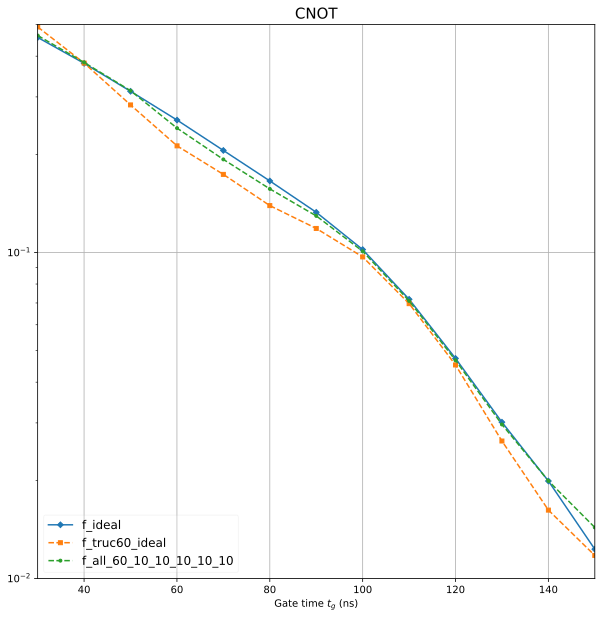

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
ms=4
ax.plot(cnot['tg'], 10**cnot['f_1000_False'], 'D-',  label=r'f_ideal', ms=ms)
# ax.plot(cnot['tg'], 10**f_100_select, '.--',  label=r'f_100_select')
# ax.plot(cnot['tg'], 10**f_70_10_select, '.--',  label=r'f_70_10_select')
# ax.plot(cnot['tg'], 10**f_all_300, '.--',  label=r'f_all_300')
# ax.plot(cnot['tg'], 10**f_all_200, '.--',  label=r'f_all_200')
# ax.plot(cnot['tg'], 10**f_all_140, '.--',  label=r'f_all_140')
# ax.plot(cnot['tg'], 10**f_all_160, '.--',  label=r'f_all_160')
# ax.plot(cnot['tg'], 10**f_all_180, '.--',  label=r'f_all_180')
# ax.plot(cnot['tg'], 10**f_all_60_20, '.--',  label=r'f_all_60_20')
# ax.plot(cnot['tg'], 10**f_all_100_20, '.--',  label=r'f_all_100_20')
# ax.plot(cnot['tg'], 10**f_all_120_20, '.--',  label=r'f_all_120_20')
ax.plot(cnot['tg'], 10**sorted_arr[:,5], 's--',  label=r'f_truc60_ideal', ms=ms)
# ax.plot(cnot['tg'], 10**f_all_120_40, '.--',  label=r'f_all_120_40')
# ax.plot(cnot['tg'], 10**f_all_120_30, '.--',  label=r'f_all_120_30')
# ax.plot(cnot['tg'], 10**f_all_120_10_10, '.--',  label=r'f_all_120_10_10')
# ax.plot(cnot['tg'], 10**f_all_100_10_10_10, '.--',  label=r'f_all_100_10_10_10')
# ax.plot(cnot['tg'], 10**f_all_75_10_10_10_10, '.--',  label=r'f_all_75_10_10_10_10')
# ax.plot(cnot['tg'], 10**f_all_65_10_10_10_10, '.--',  label=r'f_all_65_10_10_10_10')
ax.plot(cnot['tg'], 10**f_all_60_10_10_10_10_10, '.--',  label=r'f_all_60_10_10_10_10_10')
plt.xlim(30,150)
plt.ylim(1e-2, 5e-1)
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.title(r'CNOT', fontsize=15)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent